In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import os
import json
import copy
from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import Levenshtein

In [2]:
# ========== CONFIGURATION ==========
BATCH_SIZE = 16
HIDDEN_DIM = 512      # Set based on your VRAM (try 512 if possible, else 384 or 256)
EMB_DIM = 384         # Embedding size, can match HIDDEN_DIM
ROW_BI_DIM = 64
NUM_LAYERS = 2
DROPOUT = 0.3
LEARNING_RATE = 1e-4
LABEL_SMOOTH = 0.2
USE_FOCAL_LOSS = True   # Set to True to enable label smoothing + focal loss
GAMMA_FOCAL = 2.0        # Focal loss focusing parameter
NUM_EPOCHS = 50
BEAM_WIDTH = 5
MAX_LEN = 160

In [3]:
data_dir = r"C:\Users\gurpr\final_six_months_project\dataset"
images_dir = os.path.join(data_dir, "processed_images")
train_json = os.path.join(data_dir, "train_dataset.json")
val_json = os.path.join(data_dir, "val_dataset.json")
test_json = os.path.join(data_dir, "test_dataset.json")
vocab_json = os.path.join(data_dir, "vocab.json")
checkpoint_path =  r"C:\Users\gurpr\final_six_months_project\model_checkpoint\full_checkpoint.pt"  # For full training state

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda", "CUDA GPU is required for efficient training!"

In [5]:
# ========== Load vocab ==========
with open(vocab_json, "r", encoding="utf-8") as f:
    vocab = json.load(f)
pad_token_id = vocab["<PAD>"]
sos_token_id = vocab["<SOS>"]
eos_token_id = vocab["<EOS>"]
unk_token_id = vocab["<UNK>"]
vocab_size = len(vocab)
idx_to_token = {v: k for k, v in vocab.items()}

In [6]:
class Im2LatexDataset(torch.utils.data.Dataset):
    def __init__(self, json_path, images_dir):
        with open(json_path, "r", encoding="utf-8") as f:
            self.data = json.load(f)
        self.images_dir = images_dir
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        sample = self.data[idx]
        img_path = os.path.join(self.images_dir, sample["image"])
        image = torch.from_numpy(np.load(img_path)).float()
        seq = torch.tensor(sample["token_ids"], dtype=torch.long)
        return image, seq

from torch.nn.utils.rnn import pad_sequence
def collate_fn(batch):
    images, seqs = zip(*batch)
    images = [img.unsqueeze(0) for img in images]  # [1, H, W]
    images = torch.stack(images)
    seqs_padded = pad_sequence(seqs, batch_first=True, padding_value=pad_token_id)
    lengths = torch.tensor([len(seq) for seq in seqs], dtype=torch.long)
    return images, seqs_padded, lengths

In [7]:
train_dataset = Im2LatexDataset(train_json, images_dir)
val_dataset = Im2LatexDataset(val_json, images_dir)
test_dataset = Im2LatexDataset(test_json, images_dir)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}, Test size: {len(test_dataset)}")

Train size: 75243, Val size: 8365, Test size: 10279


In [8]:
# ========== Model Classes ==========

# ========== Depthwise Separable Convolution Block ==========
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size, stride, padding, groups=in_channels, bias=False)
        self.pointwise = nn.Conv2d(in_channels, out_channels, 1, 1, 0, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.act = nn.ReLU(inplace=True)
    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.bn(x)
        x = self.act(x)
        return x

In [9]:
# ========== Spatial Attention ==========
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg_out, max_out], dim=1)
        attn = self.conv(x_cat)
        attn = self.sigmoid(attn)
        return x * attn

In [10]:
# ========== LWDSCSA Encoder with Row BiLSTM ==========
class LWDSCSA_Encoder(nn.Module):
    def __init__(self, in_channels=1, hidden_dims=[32, 64, 128], strides=[2, 2, 1], row_hidden_dim=64):
        super().__init__()
        assert len(hidden_dims) == len(strides), "hidden_dims and strides must have same length"
        layers = []
        prev_dim = in_channels
        for hd, s in zip(hidden_dims, strides):
            layers.append(DepthwiseSeparableConv(prev_dim, hd, 3, stride=s, padding=1))
            prev_dim = hd
        self.dsc_blocks = nn.Sequential(*layers)
        self.spatial_att = SpatialAttention()
        self.row_hidden_dim = row_hidden_dim
        self.row_bilstm = nn.LSTM(
            input_size=hidden_dims[-1],
            hidden_size=row_hidden_dim,
            batch_first=True,
            bidirectional=True
        )
    def forward(self, x):
        feat = self.dsc_blocks(x)      # [B, C, H, W]
        feat = self.spatial_att(feat)  # [B, C, H, W]
        B, C, H, W = feat.shape
        # Row BiLSTM: run over each row
        feat_reshape = feat.permute(0, 2, 3, 1).contiguous().view(B*H, W, C)  # [B*H, W, C]
        row_out, _ = self.row_bilstm(feat_reshape)                            # [B*H, W, 2*row_hidden_dim]
        row_out = row_out.reshape(B, H, W, 2*self.row_hidden_dim)
        row_out = row_out.permute(0, 2, 1, 3).contiguous()    # [B, W, H, 2*row_hidden_dim]
        row_out = row_out.reshape(B, W, H*2*self.row_hidden_dim)
        return row_out   # [B, W, H*2*row_hidden_dim]

In [11]:
# ========== Sequence Model (BiLSTM) ==========
class SequenceModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=2, dropout=0.3):
        super().__init__()
        self.bilstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
    def forward(self, x):
        output, _ = self.bilstm(x)
        return output

In [12]:
# ========== Luong Attention ==========
class LuongAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
    def forward(self, decoder_hidden, encoder_outputs):
        attn_energies = torch.bmm(
            encoder_outputs, decoder_hidden.unsqueeze(2)
        ).squeeze(2)
        attn_weights = torch.softmax(attn_energies, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)
        return context, attn_weights

In [13]:
# ========== Luong Decoder (with projection) ==========
class LuongDecoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, enc_hidden_dim, dec_hidden_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.rnn = nn.LSTM(emb_dim + enc_hidden_dim, dec_hidden_dim, batch_first=True)
        self.attn = LuongAttention(enc_hidden_dim)
        self.out = nn.Linear(dec_hidden_dim, vocab_size)
        self.hidden_proj = nn.Linear(dec_hidden_dim, enc_hidden_dim)
        self.rnn_layers = 1
        self.dec_hidden_dim = dec_hidden_dim
    def forward(self, input_token, prev_hidden, encoder_outputs):
        emb = self.embedding(input_token).unsqueeze(1)  # [B, 1, emb_dim]
        hidden_for_attn = prev_hidden[0].squeeze(0)     # [B, dec_hidden_dim]
        hidden_for_attn = self.hidden_proj(hidden_for_attn)  # [B, enc_hidden_dim]
        context, attn_weights = self.attn(hidden_for_attn, encoder_outputs)
        context = context.unsqueeze(1)
        rnn_input = torch.cat([emb, context], dim=2)
        output, hidden = self.rnn(rnn_input, prev_hidden)
        output = output.squeeze(1)
        logits = self.out(output)
        return logits, hidden, attn_weights

In [14]:
# ========== Label Smoothing Loss with Focal Loss ==========
def label_smoothing_loss(logits, target, smoothing=LABEL_SMOOTH, ignore_index=None, use_focal=False, gamma=GAMMA_FOCAL):
    """
    Computes cross-entropy with label smoothing and (optionally) focal loss.
    Args:
        logits: [N, C]
        target: [N]
        smoothing: label smoothing factor (float)
        ignore_index: token index to ignore in loss
        use_focal: if True, apply focal loss modulation
        gamma: focusing parameter for focal loss
    """
    n_class = logits.size(-1)
    # --- Create label-smoothed true distribution ---
    with torch.no_grad():
        true_dist = torch.zeros_like(logits).scatter(1, target.unsqueeze(1), 1)
        true_dist = true_dist * (1 - smoothing) + (1 - true_dist) * (smoothing / (n_class - 1))

    log_probs = F.log_softmax(logits, dim=1)
    probs = torch.exp(log_probs)

    if use_focal:
        # Focal loss modulator: (1 - p_t)^gamma
        focal_weight = (1 - probs).pow(gamma)
        loss = -true_dist * focal_weight * log_probs
    else:
        loss = -true_dist * log_probs

    loss = loss.sum(dim=1)  # Sum over classes (keep batch dimension)

    if ignore_index is not None:
        mask = (target != ignore_index)
        loss = loss * mask
        return loss.sum() / mask.sum()
    return loss.mean()

In [15]:
# ========== Instantiate Model, Optimizer, Scheduler ==========
encoder = LWDSCSA_Encoder(in_channels=1, hidden_dims=[32, 64, 128], strides=[2, 2, 1], row_hidden_dim=ROW_BI_DIM).to(device)
seq_model = SequenceModel(input_dim=5120, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, dropout=DROPOUT).to(device)
decoder = LuongDecoder(vocab_size, emb_dim=EMB_DIM, enc_hidden_dim=2*HIDDEN_DIM, dec_hidden_dim=HIDDEN_DIM, dropout=DROPOUT).to(device)

params = list(encoder.parameters()) + list(seq_model.parameters()) + list(decoder.parameters())
optimizer = optim.Adam(params, lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5, min_lr=1e-7, verbose=True)

C:\Users\gurpr\myenv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [16]:
class FullIm2LatexModel(nn.Module):
    def __init__(self, encoder, seq_model, decoder, hidden_dim, sos_token_id):
        super().__init__()
        self.encoder = encoder
        self.seq_model = seq_model
        self.decoder = decoder
        self.hidden_dim = hidden_dim
        self.sos_token_id = sos_token_id

    def forward(self, x):
        # x: [B, 1, 160, 1024]
        features = self.encoder(x)                     # [B, W, H*2*row_hidden_dim]
        encoder_outputs = self.seq_model(features)     # [B, W, 2*hidden_dim]
        batch_size = x.size(0)
        # Prepare initial decoder hidden state
        hidden = (torch.zeros(1, batch_size, self.hidden_dim, device=x.device),
                  torch.zeros(1, batch_size, self.hidden_dim, device=x.device))
        # Simulate decoding for 1 step (for summary)
        input_token = torch.full((batch_size,), self.sos_token_id, dtype=torch.long, device=x.device)
        logits, hidden, attn = self.decoder(input_token, hidden, encoder_outputs)
        return logits  # [B, vocab_size]

In [17]:
from torchinfo import summary

# Instantiate the model (assuming encoder, seq_model, decoder, HIDDEN_DIM, sos_token_id, device are defined)
full_model = FullIm2LatexModel(encoder, seq_model, decoder, hidden_dim=HIDDEN_DIM, sos_token_id=sos_token_id).to(device)

# Print summary (use batch_size=2 for demonstration)
summary(full_model, input_size=(2, 1, 160, 1024), device=device, col_names=["input_size", "output_size", "num_params"])

Layer (type:depth-idx)                        Input Shape               Output Shape              Param #
FullIm2LatexModel                             [2, 1, 160, 1024]         [2, 544]                  --
├─LWDSCSA_Encoder: 1-1                        [2, 1, 160, 1024]         [2, 256, 5120]            --
│    └─Sequential: 2-1                        [2, 1, 160, 1024]         [2, 128, 40, 256]         --
│    │    └─DepthwiseSeparableConv: 3-1       [2, 1, 160, 1024]         [2, 32, 80, 512]          105
│    │    └─DepthwiseSeparableConv: 3-2       [2, 32, 80, 512]          [2, 64, 40, 256]          2,464
│    │    └─DepthwiseSeparableConv: 3-3       [2, 64, 40, 256]          [2, 128, 40, 256]         9,024
│    └─SpatialAttention: 2-2                  [2, 128, 40, 256]         [2, 128, 40, 256]         --
│    │    └─Conv2d: 3-4                       [2, 2, 40, 256]           [2, 1, 40, 256]           98
│    │    └─Sigmoid: 3-5                      [2, 1, 40, 256]           [2, 1, 

In [18]:
# ========== Training/Validation Loop ==========
train_losses, val_losses = [], []
best_val_loss = float('inf')
bad_epochs = 0
max_patience = 7

# ========== Resume logic (optional, robust) ==========
start_epoch = 1
if os.path.exists(checkpoint_path):
    print("[INFO] Loading checkpoint...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    encoder.load_state_dict(checkpoint["encoder"])
    seq_model.load_state_dict(checkpoint["seq_model"])
    decoder.load_state_dict(checkpoint["decoder"])
    optimizer.load_state_dict(checkpoint["optimizer"])
    scheduler.load_state_dict(checkpoint["scheduler"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_loss = checkpoint.get("best_val_loss", best_val_loss)
    bad_epochs = checkpoint.get("bad_epochs", 0)
    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])
    print(f"[INFO] Resuming from epoch {start_epoch}")

prev_lr = optimizer.param_groups[0]['lr']

for epoch in range(start_epoch, NUM_EPOCHS + 1):
    encoder.train(); seq_model.train(); decoder.train()
    total_train_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch} [Train]")
    for batch_idx, (images, seqs, lengths) in enumerate(pbar):
        images, seqs = images.to(device), seqs.to(device)
        optimizer.zero_grad()
        # ========== ENCODER==========
        features = encoder(images)
        # ========== SEQUENCE MODEL ==========
        encoder_outputs = seq_model(features)
        # ========== Prepare decoder initial hidden state ==========
        batch_size, src_seq_len, enc_dim = encoder_outputs.shape
        hidden = (torch.zeros(1, batch_size, HIDDEN_DIM, device=device), torch.zeros(1, batch_size, HIDDEN_DIM, device=device))
        # ========== DECODER: Teacher forcing ==========
        logits_all = []
        input_token = torch.full((batch_size,), sos_token_id, dtype=torch.long, device=device)
        for t in range(1, seqs.size(1)):
            logits, hidden, _ = decoder(input_token, hidden, encoder_outputs)
            logits_all.append(logits)
            input_token = seqs[:, t]  # Teacher forcing
        logits_all = torch.stack(logits_all, dim=1)  # [B, T-1, vocab]
        # ========== Loss ==========
        loss = label_smoothing_loss(logits_all.view(-1, vocab_size), seqs[:, 1:].contiguous().view(-1), smoothing=LABEL_SMOOTH, ignore_index=pad_token_id, use_focal=USE_FOCAL_LOSS, gamma=GAMMA_FOCAL)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
        pbar.set_postfix({"loss": loss.item()})
        if batch_idx == 0:
            print("[Debug] Encoder output shape:", encoder_outputs.shape)
            print("[Debug] Decoder logits shape:", logits_all.shape)
    train_loss = total_train_loss / len(train_loader)
    train_losses.append(train_loss)
    
    # ========== Validation ==========
    encoder.eval(); seq_model.eval(); decoder.eval()
    total_val_loss = 0
    with torch.no_grad():
        for images, seqs, lengths in tqdm(val_loader, desc=f"Epoch {epoch} [Val]"):
            images, seqs = images.to(device), seqs.to(device)
            features = encoder(images)
            encoder_outputs = seq_model(features)
            batch_size = images.size(0)
            hidden = (torch.zeros(1, batch_size, HIDDEN_DIM, device=device), torch.zeros(1, batch_size, HIDDEN_DIM, device=device))
            logits_all = []
            input_token = torch.full((batch_size,), sos_token_id, dtype=torch.long, device=device)
            for t in range(1, seqs.size(1)):
                logits, hidden, _ = decoder(input_token, hidden, encoder_outputs)
                logits_all.append(logits)
                input_token = seqs[:, t]  # Teacher forcing
            logits_all = torch.stack(logits_all, dim=1)
            loss = label_smoothing_loss(logits_all.view(-1, vocab_size), seqs[:, 1:].contiguous().view(-1), smoothing=LABEL_SMOOTH, ignore_index=pad_token_id, use_focal=USE_FOCAL_LOSS, gamma=GAMMA_FOCAL)
            total_val_loss += loss.item()
    val_loss = total_val_loss / len(val_loader)
    val_losses.append(val_loss)
    
    # ========== Scheduler & Patience Logic ==========
    prev_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)   # for ReduceLROnPlateau
    # If you use CosineAnnealing, replace with: scheduler.step(epoch)
    curr_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch}: Train Loss={train_loss:.4f} | Val Loss={val_loss:.4f} | LR={curr_lr:.8f}")

    if curr_lr < prev_lr:
        bad_epochs = 0
        print(f"  [Patience Reset] LR dropped from {prev_lr:.8f} to {curr_lr:.8f}")
    # ========== Early Stopping & Checkpoint ==========
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        bad_epochs = 0
        torch.save({
            "encoder": encoder.state_dict(),
            "seq_model": seq_model.state_dict(),
            "decoder": decoder.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict(),
            "epoch": epoch,
            "best_val_loss": best_val_loss,
            "bad_epochs": bad_epochs,
            "train_losses": train_losses,
            "val_losses": val_losses
        }, checkpoint_path)
        print("  [Checkpoint] Best model and training state saved.")
    else:
        bad_epochs += 1
        print(f"  No improvement. Patience {bad_epochs}/{max_patience}")
        if bad_epochs >= max_patience:
            print("Early stopping!")
            break

[INFO] Loading checkpoint...


C:\Users\gurpr\AppData\Local\Temp\ipykernel_16908\950143743.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device

[INFO] Resuming from epoch 35


Epoch 35 [Train]:   0%|                                                  | 1/4703 [00:01<1:20:32,  1.03s/it, loss=1.63]

[Debug] Encoder output shape: torch.Size([16, 256, 1024])
[Debug] Decoder logits shape: torch.Size([16, 106, 544])


...

Epoch 49: Train Loss=1.6058 | Val Loss=1.6434 | LR=0.00005000
  [Checkpoint] Best model and training state saved.


Epoch 50 [Train]:   0%|                                                    | 1/4703 [00:00<41:33,  1.89it/s, loss=1.59]

[Debug] Encoder output shape: torch.Size([16, 256, 1024])
[Debug] Decoder logits shape: torch.Size([16, 97, 544])


Epoch 50 [Val]: 100%|████████████████████████████████████████████████████████████████| 523/523 [02:10<00:00,  4.01it/s]


Epoch 50: Train Loss=1.6005 | Val Loss=1.6389 | LR=0.00005000
  [Checkpoint] Best model and training state saved.


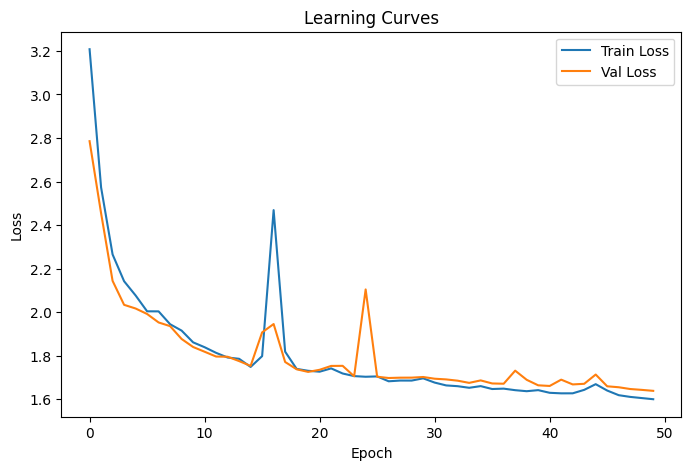

In [19]:
# ========== Plot Learning Curves ==========
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curves")
plt.legend()
plt.show()

In [18]:
# ========== Evaluation Metrics ==========
def token_accuracy(pred, target, pad_token_id):
    mask = target != pad_token_id
    correct = (pred == target) & mask
    num_correct = correct.sum().item()
    num_total = mask.sum().item()
    return num_correct, num_total

def sequence_exact_match(pred, target, pad_token_id, eos_token_id=None, sos_token_id=None):
    matches = 0
    for i in range(pred.shape[0]):
        pred_seq = pred[i].cpu().tolist()
        target_seq = target[i].cpu().tolist()
        exclude = {pad_token_id}
        if eos_token_id is not None:
            exclude.add(eos_token_id)
        if sos_token_id is not None:
            exclude.add(sos_token_id)
        pred_clean = [t for t in pred_seq if t not in exclude]
        target_clean = [t for t in target_seq if t not in exclude]
        if pred_clean == target_clean:
            matches += 1
    return matches, pred.shape[0]

def compute_bleu(ref, hyp):
    smoothie = SmoothingFunction().method4
    return sentence_bleu([ref], hyp, smoothing_function=smoothie)

def wer(ref, hyp):
    dp = np.zeros((len(ref)+1, len(hyp)+1), dtype=int)
    for i in range(len(ref)+1):
        dp[i][0] = i
    for j in range(len(hyp)+1):
        dp[0][j] = j
    for i in range(1, len(ref)+1):
        for j in range(1, len(hyp)+1):
            cost = 0 if ref[i-1] == hyp[j-1] else 1
            dp[i][j] = min(dp[i-1][j]+1, dp[i][j-1]+1, dp[i-1][j-1]+cost)
    return dp[len(ref)][len(hyp)] / max(1, len(ref))

def character_error_rate(gt, pred):
    """
    CER = (Levenshtein distance at character level) / (length of gt)
    """
    gt_str = "".join(gt) if isinstance(gt, list) else gt
    pred_str = "".join(pred) if isinstance(pred, list) else pred
    ed = Levenshtein.distance(gt_str, pred_str)
    return ed / max(1, len(gt_str))

def character_recognition_rate(gt, pred):
    """
    CRR = 1 - CER = (1 - (Levenshtein distance at character level) / (length of gt))
    """
    gt_str = "".join(gt) if isinstance(gt, list) else gt
    pred_str = "".join(pred) if isinstance(pred, list) else pred
    ed = Levenshtein.distance(gt_str, pred_str)
    return 1.0 - (ed / max(1, len(gt_str)))

def compute_edit_distances(gt_list, pred_list):
    """
    gt_list, pred_list: list of strings (or lists of tokens, which will be joined to strings)
    Returns:
        edit_distances: list of integer distances
        norm_edit_distances: list of normalized distances
    """
    edit_distances = []
    norm_edit_distances = []
    for gt, pred in zip(gt_list, pred_list):
        # If input is a list, join to string
        if isinstance(gt, list):
            gt = " ".join(gt)
        if isinstance(pred, list):
            pred = " ".join(pred)
        ed = Levenshtein.distance(gt, pred)
        norm_ed = ed / max(len(gt), 1)
        edit_distances.append(ed)
        norm_edit_distances.append(norm_ed)
    return edit_distances, norm_edit_distances

In [19]:
# ========== Decoding Functions ==========
def greedy_decode(encoder, seq_model, decoder, image, sos_token_id, eos_token_id, max_len=MAX_LEN, device='cuda'):
    encoder.eval(); seq_model.eval(); decoder.eval()
    with torch.no_grad():
        image = image.unsqueeze(0).to(device)
        features = encoder(image)
        encoder_outputs = seq_model(features)
        batch_size = 1
        hidden = (torch.zeros(1, batch_size, HIDDEN_DIM, device=device), torch.zeros(1, batch_size, HIDDEN_DIM, device=device))
        input_token = torch.tensor([sos_token_id], dtype=torch.long, device=device)
        decoded = []
        for _ in range(max_len):
            logits, hidden, _ = decoder(input_token, hidden, encoder_outputs)
            next_token = logits.argmax(-1)
            if next_token.item() == eos_token_id:
                break
            decoded.append(next_token.item())
            input_token = next_token
        return decoded

In [20]:
def beam_search_decode(encoder, seq_model, decoder, image, sos_token_id, eos_token_id, beam_width=BEAM_WIDTH, max_len=MAX_LEN, device='cuda'):
    encoder.eval(); seq_model.eval(); decoder.eval()
    with torch.no_grad():
        image = image.unsqueeze(0).to(device)
        features = encoder(image)
        encoder_outputs = seq_model(features)
        batch_size = 1
        h_0 = torch.zeros(1, batch_size, HIDDEN_DIM, device=device)
        c_0 = torch.zeros(1, batch_size, HIDDEN_DIM, device=device)
        hidden = (h_0, c_0)
        beams = [([sos_token_id], copy.deepcopy(hidden), 0.0, False)]
        for _ in range(max_len):
            new_beams = []
            for tokens, h, score, finished in beams:
                if finished:
                    new_beams.append((tokens, h, score, True))
                    continue
                input_token = torch.tensor([tokens[-1]], dtype=torch.long, device=device)
                logits, h_new, _ = decoder(input_token, h, encoder_outputs)
                log_probs = torch.nn.functional.log_softmax(logits, dim=-1).squeeze(0)
                topk_log_probs, topk_indices = torch.topk(log_probs, beam_width)
                for log_p, idx in zip(topk_log_probs.tolist(), topk_indices.tolist()):
                    next_tokens = tokens + [idx]
                    next_score = score + log_p
                    next_finished = (idx == eos_token_id)
                    new_beams.append((next_tokens, copy.deepcopy(h_new), next_score, next_finished))
            new_beams = sorted(new_beams, key=lambda x: x[2], reverse=True)[:beam_width]
            beams = new_beams
            if all([b[3] for b in beams]):
                break
        best_tokens = beams[0][0][1:]
        if eos_token_id in best_tokens:
            best_tokens = best_tokens[:best_tokens.index(eos_token_id)]
        return best_tokens

In [21]:
# ========== Load Best Model ==========
ckpt = torch.load(checkpoint_path)
encoder.load_state_dict(ckpt["encoder"])
seq_model.load_state_dict(ckpt["seq_model"])
decoder.load_state_dict(ckpt["decoder"])
encoder.eval(); seq_model.eval(); decoder.eval()
print("Best model loaded for evaluation.")

C:\Users\gurpr\AppData\Local\Temp\ipykernel_2176\2266255245.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(checkpoint_path)


Best model loaded for evaluation.


In [22]:
# ========== Final Evaluation ==========
print("\n=== GREEDY DECODING SAMPLES ===")
num_samples_to_print = 5
samples_shown = 0
bleu_scores = []
wer_scores = []
cer_scores = []
crr_scores = []
edit_distances = []
norm_edit_distances = []
token_corr = token_tot = 0
seq_corr = seq_tot = 0

for images, seqs, lengths in tqdm(test_loader, desc="Greedy Eval"):
    images, seqs = images.to(device), seqs.to(device)
    batch_size = images.size(0)
    pred_tokens_all = []
    for b in range(batch_size):
        decoded_tokens = greedy_decode(
            encoder, seq_model, decoder, images[b], sos_token_id, eos_token_id, max_len=MAX_LEN, device=device)
        pred_tensor = torch.full((seqs.size(1),), pad_token_id, dtype=torch.long, device=device)
        pred_len = min(len(decoded_tokens), seqs.size(1))
        if pred_len > 0:
            pred_tensor[:pred_len] = torch.tensor(decoded_tokens[:pred_len], device=device)
        pred_tokens_all.append(pred_tensor)

        # Remove special tokens for both pred and GT
        pred_tokens_str = [idx_to_token.get(idx, "<UNK>") for idx in decoded_tokens
                           if idx not in [pad_token_id, sos_token_id, eos_token_id]]
        gt_token_ids = seqs[b].cpu().tolist()
        gt_tokens_str = [idx_to_token.get(idx, "<UNK>") for idx in gt_token_ids
                         if idx not in [pad_token_id, sos_token_id, eos_token_id]]

        bleu_scores.append(compute_bleu(gt_tokens_str, pred_tokens_str))
        wer_scores.append(wer(gt_tokens_str, pred_tokens_str))
        gt_str = " ".join(gt_tokens_str)
        pred_str = " ".join(pred_tokens_str)
        # Inside your batch loop
        gt_chars = "".join(gt_tokens_str)  # Remove spaces to match raw LaTeX
        pred_chars = "".join(pred_tokens_str)
        cer = character_error_rate(gt_chars, pred_chars)
        cer_scores.append(cer)
        # Inside your batch loop
        gt_chars = "".join(gt_tokens_str)
        pred_chars = "".join(pred_tokens_str)
        crr = character_recognition_rate(gt_chars, pred_chars)
        crr_scores.append(crr)
        ed = Levenshtein.distance(pred_str, gt_str)
        norm_ed = ed / max(1, len(gt_str))
        edit_distances.append(ed)
        norm_edit_distances.append(norm_ed)
        if samples_shown < num_samples_to_print:
            print("="*40)
            print(f"Sample {samples_shown+1} [Greedy]")
            print(f"GT   : {gt_str}")
            print(f"PRED : {pred_str}")
            print(f"Edit Distance: {ed} | Norm Edit Distance: {norm_ed:.2%}")
            samples_shown += 1

    pred_tokens_all = torch.stack(pred_tokens_all)
    # Use improved exact match
    tc, tt = token_accuracy(pred_tokens_all[:, 1:], seqs[:, 1:], pad_token_id)
    sc, st = sequence_exact_match(pred_tokens_all, seqs, pad_token_id, eos_token_id, sos_token_id)
    token_corr += tc
    token_tot += tt
    seq_corr += sc
    seq_tot += st

print(f"Greedy - Token Accuracy: {100*token_corr/token_tot:.2f}% | Exact Match: {100*seq_corr/seq_tot:.2f}% | BLEU: {100*np.mean(bleu_scores):.2f} | WER: {100*np.mean(wer_scores):.2f}%")
print(f"Greedy - Edit Distance: mean={np.mean(edit_distances):.2f} | median={np.median(edit_distances):.2f}")
print(f"Greedy - Norm Edit Distance: mean={np.mean(norm_edit_distances):.2%} | median={np.median(norm_edit_distances):.2%}")
print(f"Greedy - CER: mean={np.mean(cer_scores):.2%} | median={np.median(cer_scores):.2%}")
print(f"Greedy - CRR: mean={np.mean(crr_scores):.2%} | median={np.median(crr_scores):.2%}")


=== GREEDY DECODING SAMPLES ===


Greedy Eval:   0%|                                                                             | 0/643 [00:00<?, ?it/s]

Sample 1 [Greedy]
GT   : \alpha _ { 1 } ^ { r } \gamma _ { 1 } + \dots + \alpha _ { N } ^ { r } \gamma _ { N } = 0 \quad ( r = 1 , . . . , R ) \; ,
PRED : \alpha _ { 1 } ^ { r } \gamma _ { 1 } + \ldots + \alpha _ { N } ^ { r } \gamma _ { N } = 0 \quad ( r = 1 , . . . , R ) \; ,
Edit Distance: 1 | Norm Edit Distance: 0.82%
Sample 2 [Greedy]
GT   : \eta = - \frac { 1 } { 2 } \operatorname { l n } \left( \frac { \operatorname { c o s h } \left( \sqrt { 2 } b _ { \infty } \sqrt { 1 + \alpha ^ { 2 } } \; y - \mathrm { a r c s i n h } \; \alpha \right) } { \sqrt { 1 + \alpha ^ { 2 } } } \right)
PRED : \eta = - \frac { 1 } { 2 } \operatorname { l n } \left( \frac { \operatorname { c o s h } \left( \sqrt { 2 } b _ { \infty } \sqrt { 1 + \alpha ^ { 2 } \, y - \operatorname { a r c s i n h } \alpha \right) } } { \sqrt { 1 + \alpha ^ { 2 } } } \right)
Edit Distance: 16 | Norm Edit Distance: 6.50%
Sample 3 [Greedy]
GT   : P _ { ( 2 ) } ^ { - } = \int \beta d \beta d ^ { 9 } p d ^ { 8 } \lambda \Ph

Greedy Eval: 100%|███████████████████████████████████████████████████████████████████| 643/643 [11:47<00:00,  1.10s/it]

Greedy - Token Accuracy: 5.33% | Exact Match: 33.43% | BLEU: 86.00 | WER: 9.96%
Greedy - Edit Distance: mean=21.49 | median=5.00
Greedy - Norm Edit Distance: mean=8.82% | median=4.06%
Greedy - CER: mean=10.15% | median=4.26%
Greedy - CRR: mean=89.85% | median=95.74%


In [23]:
# ========== Beam search decode ==========
bleu_scores = []
wer_scores = []
cer_scores = []
crr_scores = []
token_corr = token_tot = 0
seq_corr = seq_tot = 0
samples_shown = 0
edit_distances = []
norm_edit_distances = []

print("\n=== BEAM SEARCH DECODING SAMPLES ===")
for images, seqs, lengths in tqdm(test_loader, desc="Beam Search Eval"):
    images, seqs = images.to(device), seqs.to(device)
    batch_size = images.size(0)
    pred_tokens_all = []
    for b in range(batch_size):
        decoded_tokens = beam_search_decode(
            encoder, seq_model, decoder, images[b], sos_token_id, eos_token_id,
            beam_width=BEAM_WIDTH, max_len=MAX_LEN, device=device
        )
        pred_tensor = torch.full((seqs.size(1),), pad_token_id, dtype=torch.long, device=device)
        pred_len = min(len(decoded_tokens), seqs.size(1))
        if pred_len > 0:
            pred_tensor[:pred_len] = torch.tensor(decoded_tokens[:pred_len], device=device)
        pred_tokens_all.append(pred_tensor)

        # Remove special tokens for both pred and GT
        pred_tokens_str = [idx_to_token.get(idx, "<UNK>") for idx in decoded_tokens
                           if idx not in [pad_token_id, sos_token_id, eos_token_id]]
        gt_token_ids = seqs[b].cpu().tolist()
        gt_tokens_str = [idx_to_token.get(idx, "<UNK>") for idx in gt_token_ids
                         if idx not in [pad_token_id, sos_token_id, eos_token_id]]

        bleu_scores.append(compute_bleu(gt_tokens_str, pred_tokens_str))
        wer_scores.append(wer(gt_tokens_str, pred_tokens_str))
        gt_str = " ".join(gt_tokens_str)
        pred_str = " ".join(pred_tokens_str)
        # Inside your batch loop
        gt_chars = "".join(gt_tokens_str)  # Remove spaces to match raw LaTeX
        pred_chars = "".join(pred_tokens_str)
        cer = character_error_rate(gt_chars, pred_chars)
        cer_scores.append(cer)
        # Inside your batch loop
        gt_chars = "".join(gt_tokens_str)
        pred_chars = "".join(pred_tokens_str)
        crr = character_recognition_rate(gt_chars, pred_chars)
        crr_scores.append(crr)
        ed = Levenshtein.distance(pred_str, gt_str)
        norm_ed = ed / max(1, len(gt_str))
        edit_distances.append(ed)
        norm_edit_distances.append(norm_ed)
        if samples_shown < num_samples_to_print:
            print("="*40)
            print(f"Sample {samples_shown+1} [Beam]")
            print(f"GT   : {gt_str}")
            print(f"PRED : {pred_str}")
            print(f"Edit Distance: {ed} | Norm Edit Distance: {norm_ed:.2%}")
            samples_shown += 1

    pred_tokens_all = torch.stack(pred_tokens_all)
    # Use improved exact match
    tc, tt = token_accuracy(pred_tokens_all[:, 1:], seqs[:, 1:], pad_token_id)
    sc, st = sequence_exact_match(pred_tokens_all, seqs, pad_token_id, eos_token_id, sos_token_id)
    token_corr += tc
    token_tot += tt
    seq_corr += sc
    seq_tot += st

print(f"Beam - Token Accuracy: {100*token_corr/token_tot:.2f}% | Exact Match: {100*seq_corr/seq_tot:.2f}% | BLEU: {100*np.mean(bleu_scores):.2f} | WER: {100*np.mean(wer_scores):.2f}%")
print(f"Beam - Edit Distance: mean={np.mean(edit_distances):.2f} | median={np.median(edit_distances):.2f}")
print(f"Beam - Norm Edit Distance: mean={np.mean(norm_edit_distances):.2%} | median={np.median(norm_edit_distances):.2%}")
print(f"Beam - CER: mean={np.mean(cer_scores):.2%} | median={np.median(cer_scores):.2%}")
print(f"Beam - CRR: mean={np.mean(crr_scores):.2%} | median={np.median(crr_scores):.2%}")


=== BEAM SEARCH DECODING SAMPLES ===


Beam Search Eval:   0%|                                                                        | 0/643 [00:00<?, ?it/s]

Sample 1 [Beam]
GT   : \alpha _ { 1 } ^ { r } \gamma _ { 1 } + \dots + \alpha _ { N } ^ { r } \gamma _ { N } = 0 \quad ( r = 1 , . . . , R ) \; ,
PRED : \alpha _ { 1 } ^ { r } \gamma _ { 1 } + \ldots + \alpha _ { N } ^ { r } \gamma _ { N } = 0 \quad ( r = 1 , . . . , R ) \; ,
Edit Distance: 1 | Norm Edit Distance: 0.82%
Sample 2 [Beam]
GT   : \eta = - \frac { 1 } { 2 } \operatorname { l n } \left( \frac { \operatorname { c o s h } \left( \sqrt { 2 } b _ { \infty } \sqrt { 1 + \alpha ^ { 2 } } \; y - \mathrm { a r c s i n h } \; \alpha \right) } { \sqrt { 1 + \alpha ^ { 2 } } } \right)
PRED : \eta = - \frac { 1 } { 2 } \operatorname { l n } \left( \frac { \operatorname { c o s h } \left( \sqrt { 2 } b _ { \infty } \sqrt { 1 + \alpha ^ { 2 } } \, y - \operatorname { a r c s i n h } \alpha \right) } { \sqrt { 1 + \alpha ^ { 2 } } } \right)
Edit Distance: 12 | Norm Edit Distance: 4.88%
Sample 3 [Beam]
GT   : P _ { ( 2 ) } ^ { - } = \int \beta d \beta d ^ { 9 } p d ^ { 8 } \lambda \Phi ( - 

Beam Search Eval: 100%|████████████████████████████████████████████████████████████| 643/643 [1:23:30<00:00,  7.79s/it]

Beam - Token Accuracy: 5.11% | Exact Match: 30.90% | BLEU: 84.99 | WER: 10.03%
Beam - Edit Distance: mean=23.15 | median=8.00
Beam - Norm Edit Distance: mean=9.21% | median=4.63%
Beam - CER: mean=10.36% | median=4.85%
Beam - CRR: mean=89.64% | median=95.15%


In [24]:
import cv2
import numpy as np
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda", "CUDA GPU is required for efficient training!"

In [25]:
IMG_HEIGHT, IMG_WIDTH = 160, 1024

def preprocess_equation_image_for_inference(image_path):
    # 1. Load as grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Error loading image: {image_path}")

    # 2. Crop extra white spaces
    _, thresh = cv2.threshold(img, 240, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(255 - thresh)
    x, y, w, h = cv2.boundingRect(coords)
    cropped = img[y:y+h, x:x+w]

    # 3. Enhance sharpness & contrast
    pil_img = Image.fromarray(cropped)
    sharpness = ImageEnhance.Sharpness(pil_img).enhance(2.0)
    contrast = ImageEnhance.Contrast(sharpness).enhance(1.5)
    img = np.array(contrast)

    # 4. Binarization (optional)
    _, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 5. Resize to (160, 1024)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_AREA)

    # 6. Normalize and convert to tensor
    img_norm = img.astype(np.float32) / 255.0
    img_tensor = torch.from_numpy(img_norm).unsqueeze(0).unsqueeze(0)  # [1, 1, 160, 1024]
    return img_tensor, img  # Return both tensor and final processed image for display

In [26]:
# ========== Example usage ==========
image_path =  r"C:\Users\gurpr\final_six_months_project\dataset\formula_images\5a5b0ce6e9.png"
img_tensor, processed_img_for_plot = preprocess_equation_image_for_inference(image_path)

# ========== Model Inference ==========
def predict_latex(image_tensor, encoder, seq_model, decoder, sos_token_id, eos_token_id, idx_to_token, max_len=160, beam_width=5, mode="greedy", device="cuda"):
    encoder.eval(); seq_model.eval(); decoder.eval()
    with torch.no_grad():
        features = encoder(image_tensor)
        encoder_outputs = seq_model(features)
        batch_size = 1
        hidden = (
            torch.zeros(1, batch_size, decoder.dec_hidden_dim, device=device),
            torch.zeros(1, batch_size, decoder.dec_hidden_dim, device=device)
        )

        if mode == "greedy":
            input_token = torch.full((batch_size,), sos_token_id, dtype=torch.long, device=device)
            pred_ids = []
            for t in range(max_len):
                logits, hidden, _ = decoder(input_token, hidden, encoder_outputs)
                next_token = logits.argmax(dim=1)
                if next_token.item() == eos_token_id:
                    break  # Do not append EOS to output
                pred_ids.append(next_token.item())
                input_token = next_token
            pred_tokens = [idx_to_token.get(idx, "<UNK>") for idx in pred_ids]
            return " ".join(pred_tokens)

        elif mode == "beam":
            # Re-use your batch=1 logic (can call your beam_search_decode)
            decoded_tokens = beam_search_decode(
                encoder, seq_model, decoder, image_tensor.squeeze(0),  # Remove batch dim if present
                sos_token_id, eos_token_id, beam_width=beam_width,
                max_len=max_len, device=device
            )
            pred_tokens = [idx_to_token.get(idx, "<UNK>") for idx in decoded_tokens]
            return " ".join(pred_tokens)
        else:
            raise ValueError("Unknown decoding mode. Use 'greedy' or 'beam'.")

Greedy Decoding: I _ { L } ( p ) = ( - i ) ^ { n + 1 } \int q . d ^ { 2 \omega } \int _ { 0 } ^ { \infty } d \alpha _ { 1 } \cdots d \alpha _ { n } d \beta \cdot q ^ { - } . e ^ { i ( \sum _ { n } ^ { n } \alpha _ { i } f ( q x ) + \beta q ^ { + } q ^ { - } ] } .
Beam Search Decoding: I _ { L } ( p ) = ( - i ) ^ { n + 1 } \int q . d ^ { 2 \omega } \int _ { 0 } ^ { \infty } d \alpha _ { 1 } \cdots d \alpha _ { n } d \beta \cdot q ^ { - } . e ^ { i ( \sum _ { 1 } ^ { n } \alpha _ { i } f ( q x ) + \beta q ^ { + } q ^ { - 1 } } .


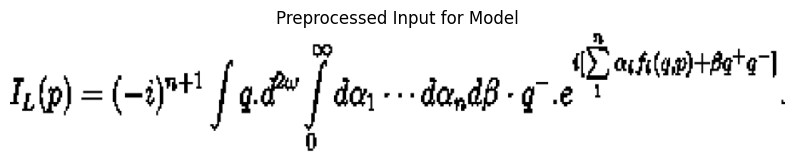

In [27]:
# Greedy decode
greedy_pred = predict_latex(
    img_tensor.to(device), encoder, seq_model, decoder,
    sos_token_id, eos_token_id, idx_to_token,
    mode="greedy"
)
print("Greedy Decoding:", greedy_pred)

# Beam search decode
beam_pred = predict_latex(
    img_tensor.to(device), encoder, seq_model, decoder,
    sos_token_id, eos_token_id, idx_to_token,
    beam_width=5, mode="beam"
)
print("Beam Search Decoding:", beam_pred)

# ========== Display processed image ==========
plt.figure(figsize=(10, 3))
plt.imshow(processed_img_for_plot, cmap='gray')
plt.title("Preprocessed Input for Model")
plt.axis('off')
plt.show()